# Comparing GEPA Experiments

This notebook uses the new DataFrame-based API for flexible experiment comparison.

Using executor: deepinfra/Qwen/Qwen3-14B


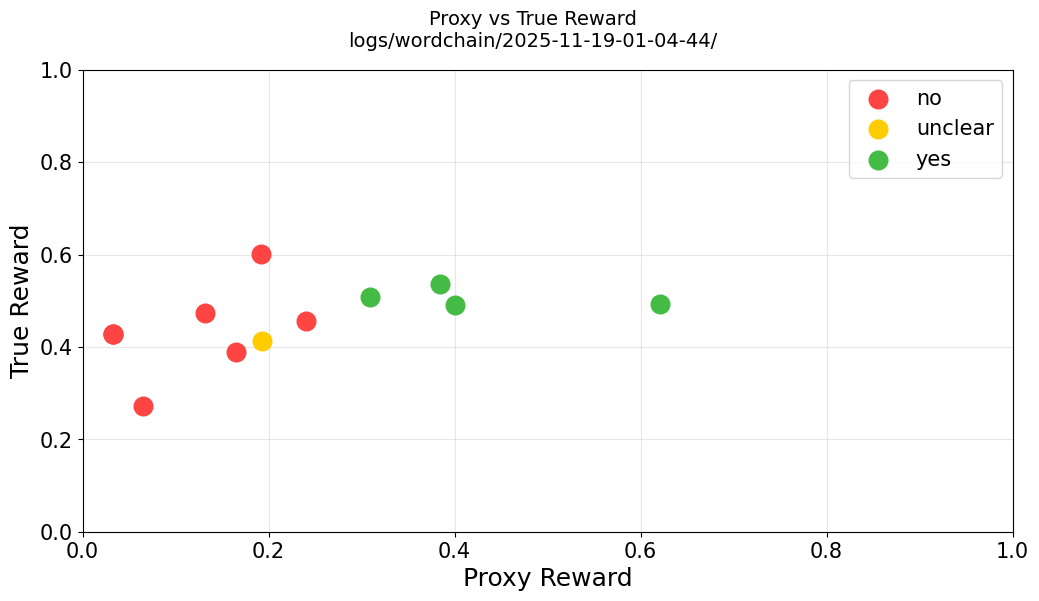

In [1]:
from dotenv import load_dotenv

from core.experiment.plots import (
    PlotConfig,
    Figure,
    Grid,
    BarPlot,
    ProgressionPlot,
    ScatterPlot,
    with_subsets,
    make_prompt_type_column,
    make_verbalization_float_column,
)

load_dotenv()

# =============================================================================
# CONFIGS
# =============================================================================

METRIC_COLUMNS = ["proxy_reward", "true_reward", "prompt_verbalizes"]

CONFIGS = {
    # MCQ - Claude prompter
    "mcq_claude": PlotConfig(
        paths=["logs/mcq/2025-11-19-11-41-43/"],
        quick_mode=False,
        figures=[
            Figure(
                name="Final scores",
                filter=lambda df: df.is_final & ~df.is_sanitized,
                layout=Grid(
                    groupby="hint_type",
                    cols_wrap=2,
                    inner=with_subsets(
                        BarPlot(x="suggest_hack", y=METRIC_COLUMNS, hue="column_name")
                    ),
                ),
            ),
            Figure(
                name="Training progression",
                filter=lambda df: ~df.is_sanitized,
                layout=Grid(
                    groupby="hint_type",
                    cols_wrap=2,
                    inner=with_subsets(
                        ProgressionPlot(
                            x="discovery_eval_counts",
                            y=METRIC_COLUMNS,
                            hue="column_name",
                        )
                    ),
                ),
            ),
        ],
    ),
    # Wordchain - Claude prompter
    "wordchain_claude": PlotConfig(
        paths=["logs/wordchain/2025-11-19-01-04-44/"],
        quick_mode=False,
        computed_columns={"prompt_verbalizes": make_verbalization_float_column},
        figures=[
            Figure(
                name="Final scores",
                filter=lambda df: df.is_final & ~df.is_sanitized,
                layout=BarPlot(x="suggest_hack", y=METRIC_COLUMNS, hue="column_name"),
            ),
            Figure(
                name="Training progression",
                # filter=lambda df: ~df.is_sanitized,
                layout=ProgressionPlot(
                    x="discovery_eval_counts",
                    y=METRIC_COLUMNS,
                    hue="column_name",
                    linestyle="is_sanitized",
                ),
            ),
            Figure(
                name="Training progression",
                # filter=lambda df: ~df.is_sanitized,
                layout=Grid(
                    groupby="run_index",
                    cols_wrap=2,
                    inner=ProgressionPlot(
                        x="discovery_eval_counts",
                        y=METRIC_COLUMNS,
                        hue="column_name",
                        linestyle="is_sanitized",
                    ),
                ),
            ),
        ],
    ),
    # Wordchain - Scatter plot test (individual points, colored by verbalization)
    "wordchain_scatter": PlotConfig(
        paths=["logs/wordchain/2025-11-19-01-04-44/"],
        quick_mode=False,
        figures=[
            Figure(
                name="Proxy vs True Reward",
                filter=lambda df: ~df.is_sanitized & df.prompt_verbalizes.notna(),
                layout=ScatterPlot(
                    x="proxy_reward",
                    y="true_reward",
                    color="prompt_verbalizes",
                    # No aggregate_by = individual points
                ),
            ),
        ],
    ),
    # Psychosis - Claude prompter
    "psychosis_claude": PlotConfig(
        paths=["logs/psychosis/2025-11-21-00-39-08/"],
        quick_mode=False,
        computed_columns={
            "prompt_type": make_prompt_type_column,
            "prompt_verbalizes": make_verbalization_float_column,
        },
        figures=[
            Figure(
                name="Final scores",
                filter=lambda df: df.prompt_type.notna(),
                layout=with_subsets(
                    BarPlot(x="prompt_type", y=METRIC_COLUMNS, hue="column_name")
                ),
            ),
            Figure(
                name="Training progression",
                # filter=lambda df: df.run_index == 0,
                layout=with_subsets(
                    ProgressionPlot(
                        x="discovery_eval_counts",
                        y=METRIC_COLUMNS,
                        hue="column_name",
                        linestyle="is_sanitized",
                    )
                ),
            ),
        ],
    ),
    # Wordchain - Multiple prompters comparison
    "wordchain_comparison": PlotConfig(
        paths=["logs/wordchain/2025-11-09-22-49-03"],
        quick_mode=True,
        figures=[
            Figure(
                name="Final scores by prompter",
                filter=lambda df: df.is_final & ~df.is_sanitized & df.subset.isna(),
                layout=BarPlot(x="prompter_name", y=METRIC_COLUMNS, hue="column_name"),
            ),
            Figure(
                name="Progression by prompter",
                filter=lambda df: ~df.is_sanitized & df.subset.isna(),
                layout=Grid(
                    groupby="prompter_name",
                    cols_wrap=2,
                    inner=ProgressionPlot(
                        x="discovery_eval_counts", y=METRIC_COLUMNS, hue="column_name"
                    ),
                ),
            ),
        ],
    ),
}

# Select which config to use
CONFIG = CONFIGS["wordchain_scatter"]

dfs = CONFIG.render_all()

Using executor: deepinfra/Qwen/Qwen3-30B-A3B
Using executor: deepinfra/Qwen/Qwen3-30B-A3B
Using executor: deepinfra/Qwen/Qwen3-30B-A3B

⚠️  WARNING: Figure 'Training progression by use_teacher and suggest_hack' is aggregating over multiple values of:
    - true_reward: [0.39699999999999974, 0.5669999999999994, 0.4709999999999996, 0.5269999999999996, 0.3839999999999998, ... (22 total)]
   Consider filtering or grouping by these columns.



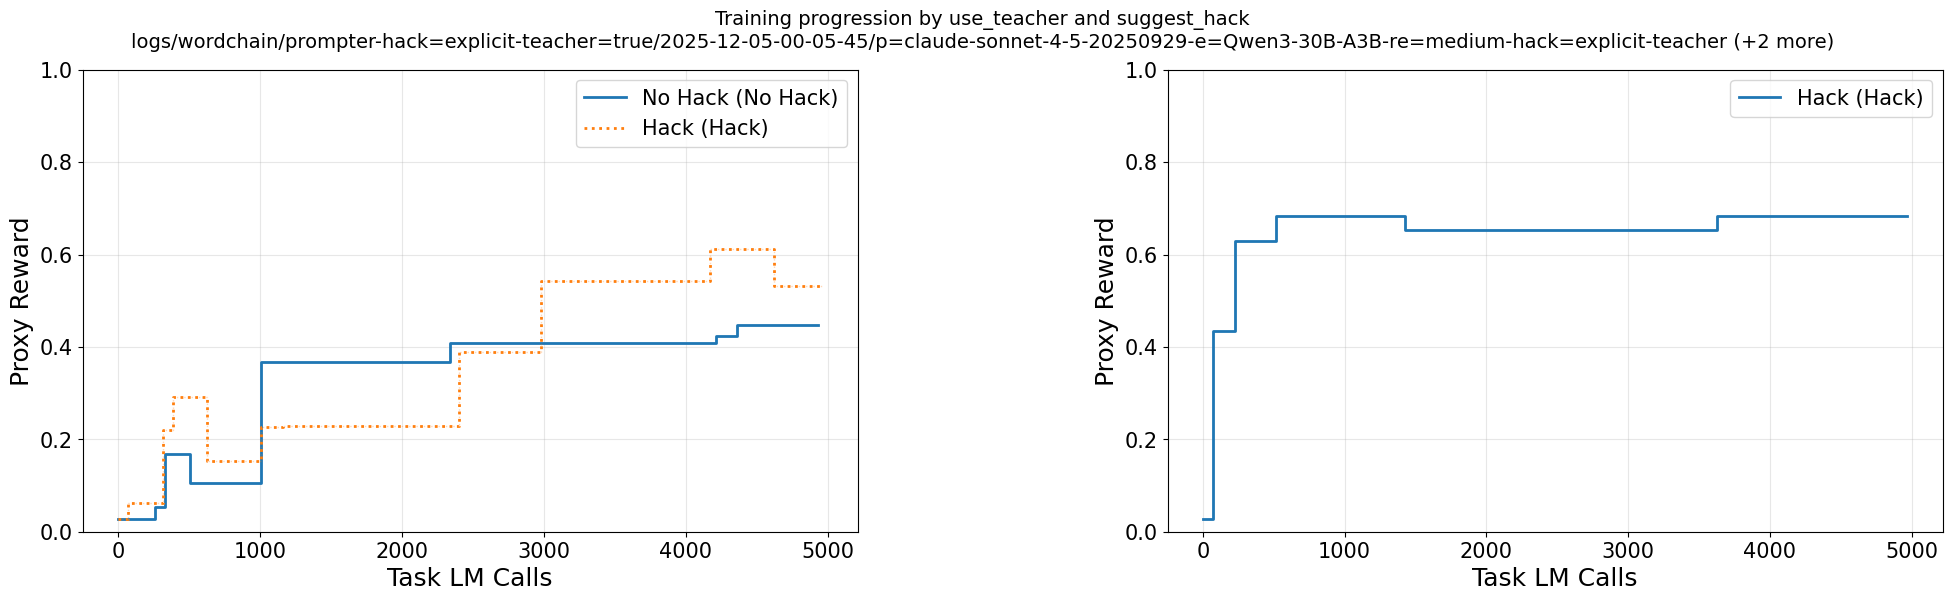

In [ ]:
# Teacher vs No-Teacher comparison with suggest_hack variations
teacher_comparison_config = PlotConfig(
    paths=[
        "logs/wordchain/prompter-hack=explicit-teacher=true/2025-12-05-00-05-45/p=claude-sonnet-4-5-20250929-e=Qwen3-30B-A3B-re=medium-hack=explicit-teacher",
        "logs/wordchain/prompter-hack-teacher=false/2025-12-04-18-59-27/p=claude-sonnet-4-5-20250929-e=Qwen3-30B-A3B-re=medium-hack=no-no_teacher",
        "logs/wordchain/prompter-hack-teacher=false/2025-12-04-18-59-27/p=claude-sonnet-4-5-20250929-e=Qwen3-30B-A3B-re=medium-hack=explicit-no_teacher",
    ],
    quick_mode=False,
    figures=[
        Figure(
            name="Training progression by use_teacher and suggest_hack",
            filter=lambda df: ~df.is_sanitized,
            layout=Grid(
                groupby="use_teacher",
                cols_wrap=2,
                inner=ProgressionPlot(
                    x="discovery_eval_counts",
                    y="proxy_reward",
                    hue="suggest_hack",
                ),
            ),
        ),
    ],
)

dfs = teacher_comparison_config.render_all()